 Data Loading and Preprocessing

In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [36]:
train_path = r"C:\Users\knite\OneDrive\Desktop\IDS PROJECT\data\Train_data.csv"
test_path = r"C:\Users\knite\OneDrive\Desktop\IDS PROJECT\data\Test_data.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())


Missing values in training data:
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

In [50]:
from sklearn.preprocessing import LabelEncoder
import joblib
train_df = pd.read_csv(r"C:\Users\knite\OneDrive\Desktop\IDS PROJECT\data\Train_data.csv")
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])  # Fit on raw strings
    joblib.dump(le, f"{col}_classes.pkl")

In [38]:
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]

X_test = test_df.copy()


Exploratory Data Analysis (EDA)

In [39]:
print("Shape of training data:", train_df.shape)
print("\nData types:")
print(train_df.dtypes)

Shape of training data: (25192, 42)

Data types:
duration                         int64
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate    

In [40]:
train_df.describe()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,25192.000000,25192.000000,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,1.053827,29.039139,6.982455,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,0.426998,15.555601,2.679322,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,19.000000,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,22.000000,9.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,46.000000,9.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,2.000000,65.000000,10.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


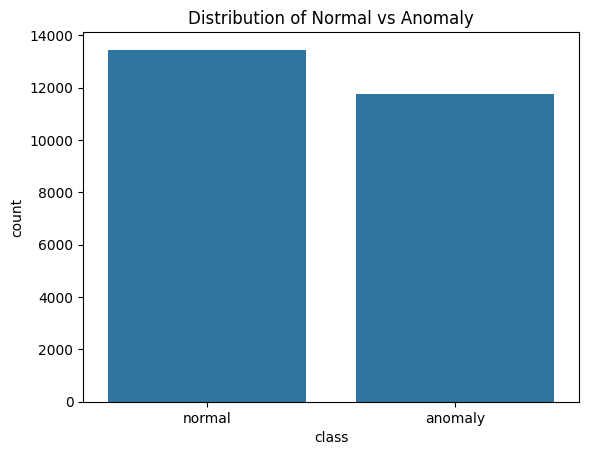

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=train_df)
plt.title("Distribution of Normal vs Anomaly")
plt.show()


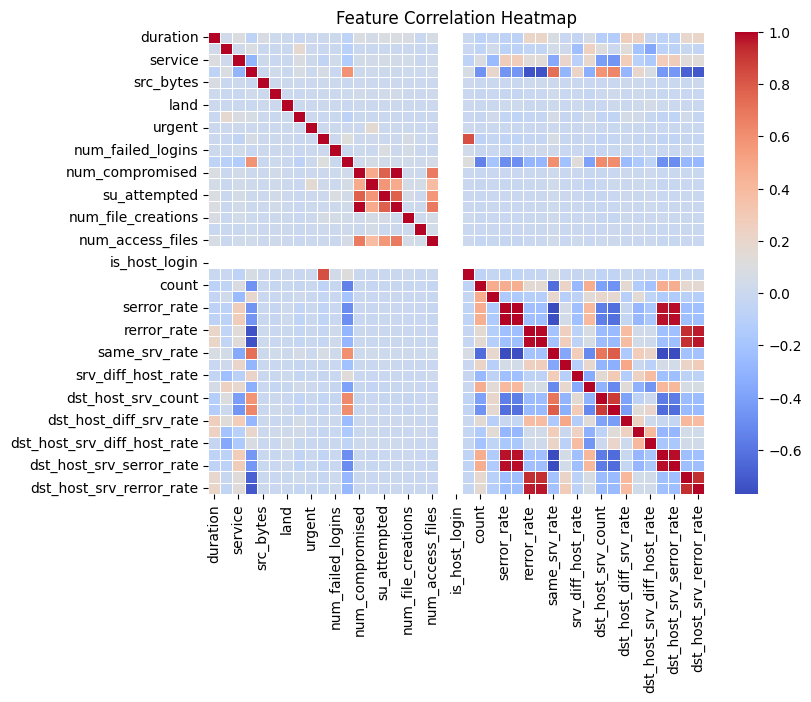

In [42]:
plt.figure(figsize=(8, 6))
correlation_matrix = train_df.drop("class", axis=1).corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


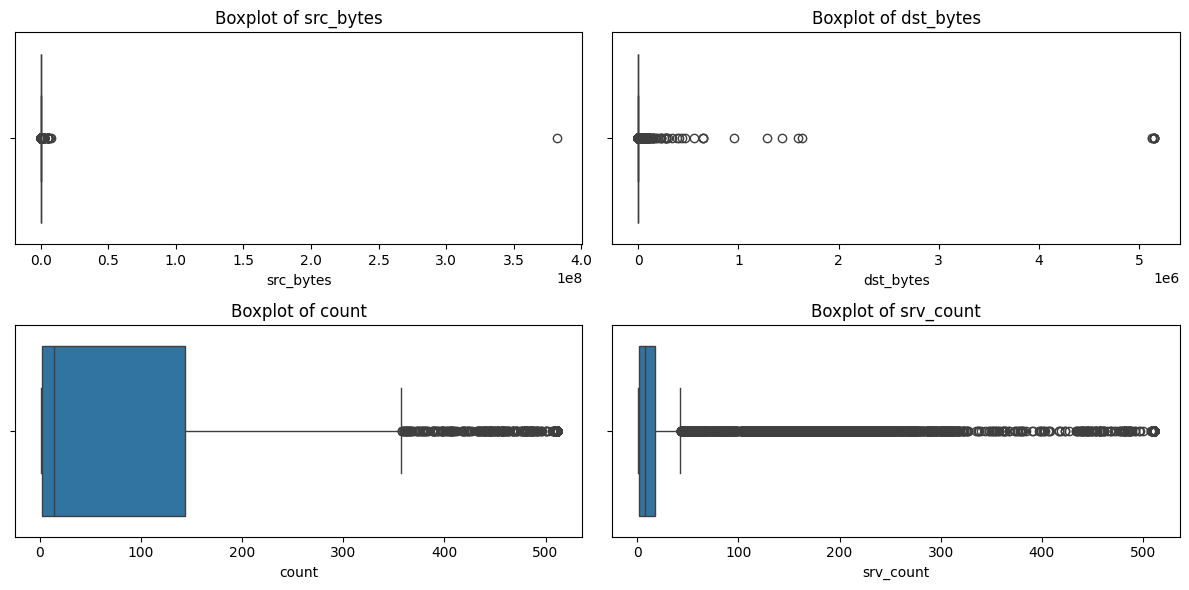

In [43]:
#outliers
features_to_plot = ['src_bytes', 'dst_bytes', 'count', 'srv_count']

#boxplots
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=train_df[feature])
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()


Data Visualization with Matplotlib and Seaborn

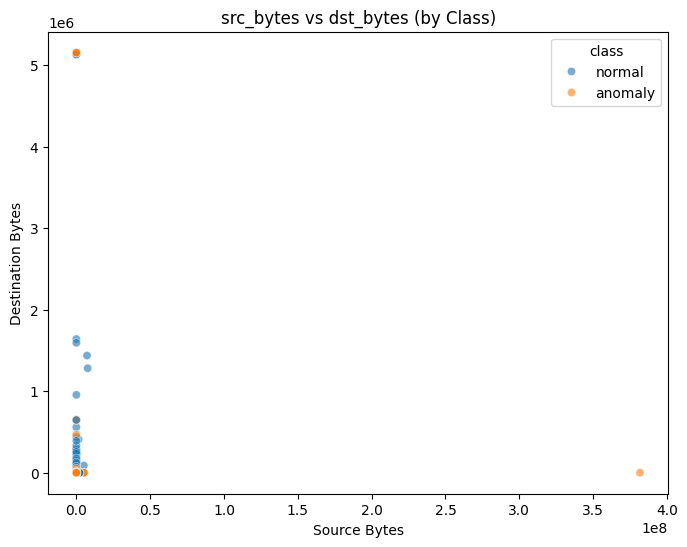

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=train_df, x='src_bytes', y='dst_bytes', hue='class', alpha=0.6)
plt.title("src_bytes vs dst_bytes (by Class)")
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")
plt.show()


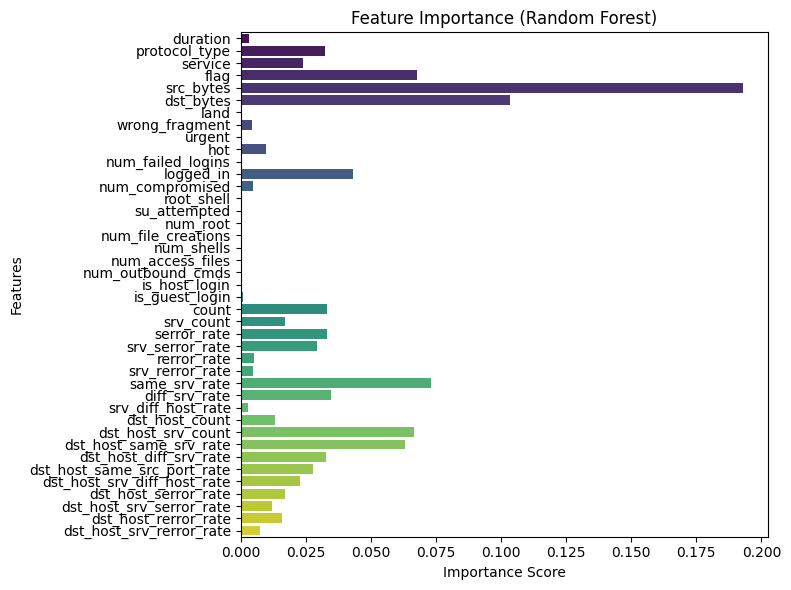

In [45]:
from sklearn.ensemble import RandomForestClassifier

X = train_df.drop("class", axis=1)
y = train_df["class"]

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(8, 6))
sns.barplot(x=importances, y=features, hue=features, palette="viridis", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


Statistical Analysis


In [46]:
train_df.describe()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,25192.000000,25192.000000,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,1.053827,29.039139,6.982455,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,0.426998,15.555601,2.679322,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,19.000000,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,22.000000,9.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,46.000000,9.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,2.000000,65.000000,10.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [47]:
from scipy.stats import ttest_ind

# Split
normal = train_df[train_df['class'] == 'normal']['src_bytes']
anomaly = train_df[train_df['class'] == 'anomaly']['src_bytes']

#t-test
t_stat, p_val = ttest_ind(normal, anomaly)

print("T-statistic:", round(t_stat, 2))
print("P-value:", round(p_val, 4))

if p_val < 0.05:
    print("Significant difference in src_bytes between normal and anomaly.")
else:
    print("No significant difference in src_bytes between normal and anomaly.")


T-statistic: -0.91
P-value: 0.3621
No significant difference in src_bytes between normal and anomaly.


Perform Statistical Tests on Features

In [53]:
import pandas as pd
import joblib

encoders = {}

for col in ['protocol_type', 'service', 'flag']:
    encoders[col] = joblib.load(f"{col}_classes.pkl")
    print(f"{col} classes: {encoders[col].classes_}")

for col in ['protocol_type', 'service', 'flag']:
    test_df[col] = test_df[col].astype(str)
    test_df[col] = test_df[col].apply(lambda x: x if x in encoders[col].classes_ else encoders[col].classes_[-1])
    test_df[col] = encoders[col].transform(test_df[col])

if 'class' in test_df.columns:
    X_test = test_df.drop("class", axis=1)
else:
    X_test = test_df.copy()

try:
    y_pred = model.predict(X_test)
    print("Predictions:", y_pred[:10])
except Exception as e:
    print(f"Error during prediction: {e}")


protocol_type classes: ['icmp' 'tcp' 'udp']
service classes: ['IRC' 'X11' 'Z39_50' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf' 'daytime'
 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs' 'exec'
 'finger' 'ftp' 'ftp_data' 'gopher' 'hostnames' 'http' 'http_443'
 'http_8001' 'imap4' 'iso_tsap' 'klogin' 'kshell' 'ldap' 'link' 'login'
 'mtp' 'name' 'netbios_dgm' 'netbios_ns' 'netbios_ssn' 'netstat' 'nnsp'
 'nntp' 'ntp_u' 'other' 'pm_dump' 'pop_2' 'pop_3' 'printer' 'private'
 'red_i' 'remote_job' 'rje' 'shell' 'smtp' 'sql_net' 'ssh' 'sunrpc'
 'supdup' 'systat' 'telnet' 'tim_i' 'time' 'urh_i' 'urp_i' 'uucp'
 'uucp_path' 'vmnet' 'whois']
flag classes: ['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']
Predictions: ['anomaly' 'anomaly' 'normal' 'anomaly' 'normal' 'normal' 'normal'
 'normal' 'normal' 'normal']


Validation Accuracy: 0.997618417570786

Classification Report:
              precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      3516
      normal       1.00      1.00      1.00      4042

    accuracy                           1.00      7558
   macro avg       1.00      1.00      1.00      7558
weighted avg       1.00      1.00      1.00      7558



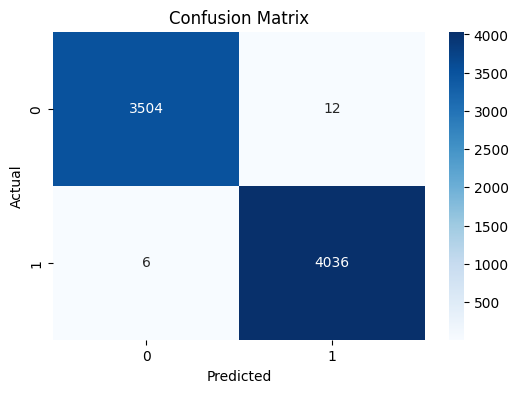

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Splitting training data to new train
X = train_df.drop("class", axis=1)
y = train_df["class"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_val)
print("Validation Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
